In [31]:
from pathlib import Path

import einops
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr

In [13]:
results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/old/0411_1805_loth_baker_corrs_30_100")

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")
db = sr.db.DB(db_ffp)

In [3]:
sc_results_df = pd.read_parquet(results_dir / "val_scenario_results.parquet")

In [6]:
prob_cols = np.char.add(sr.constants.PSA_KEYS, "_prob") 

In [28]:
event = "2013p750727"
site_int = "ARKS"

sc_results_df = sc_results_df[(sc_results_df["event_id"] == event) & (sc_results_df["site_int"] == site_int)].set_index("rel_id").sort_index()
sim_df = db.get_sim_data(event, [site_int]).set_index("rel_id").sort_index()

In [50]:
assert np.all(sc_results_df.index.values == sim_df.index.values)

prob_values = sc_results_df[prob_cols].values
sim_values = sim_df[sr.constants.PSA_KEYS].values

## Non-Logspace

In [ ]:
mean_values = einops.einsum(prob_values, sim_values, "rel im, rel im -> im")
std_values = np.sqrt(np.sum(prob_values * (sim_values - mean_values[None, :])**2, axis=0))

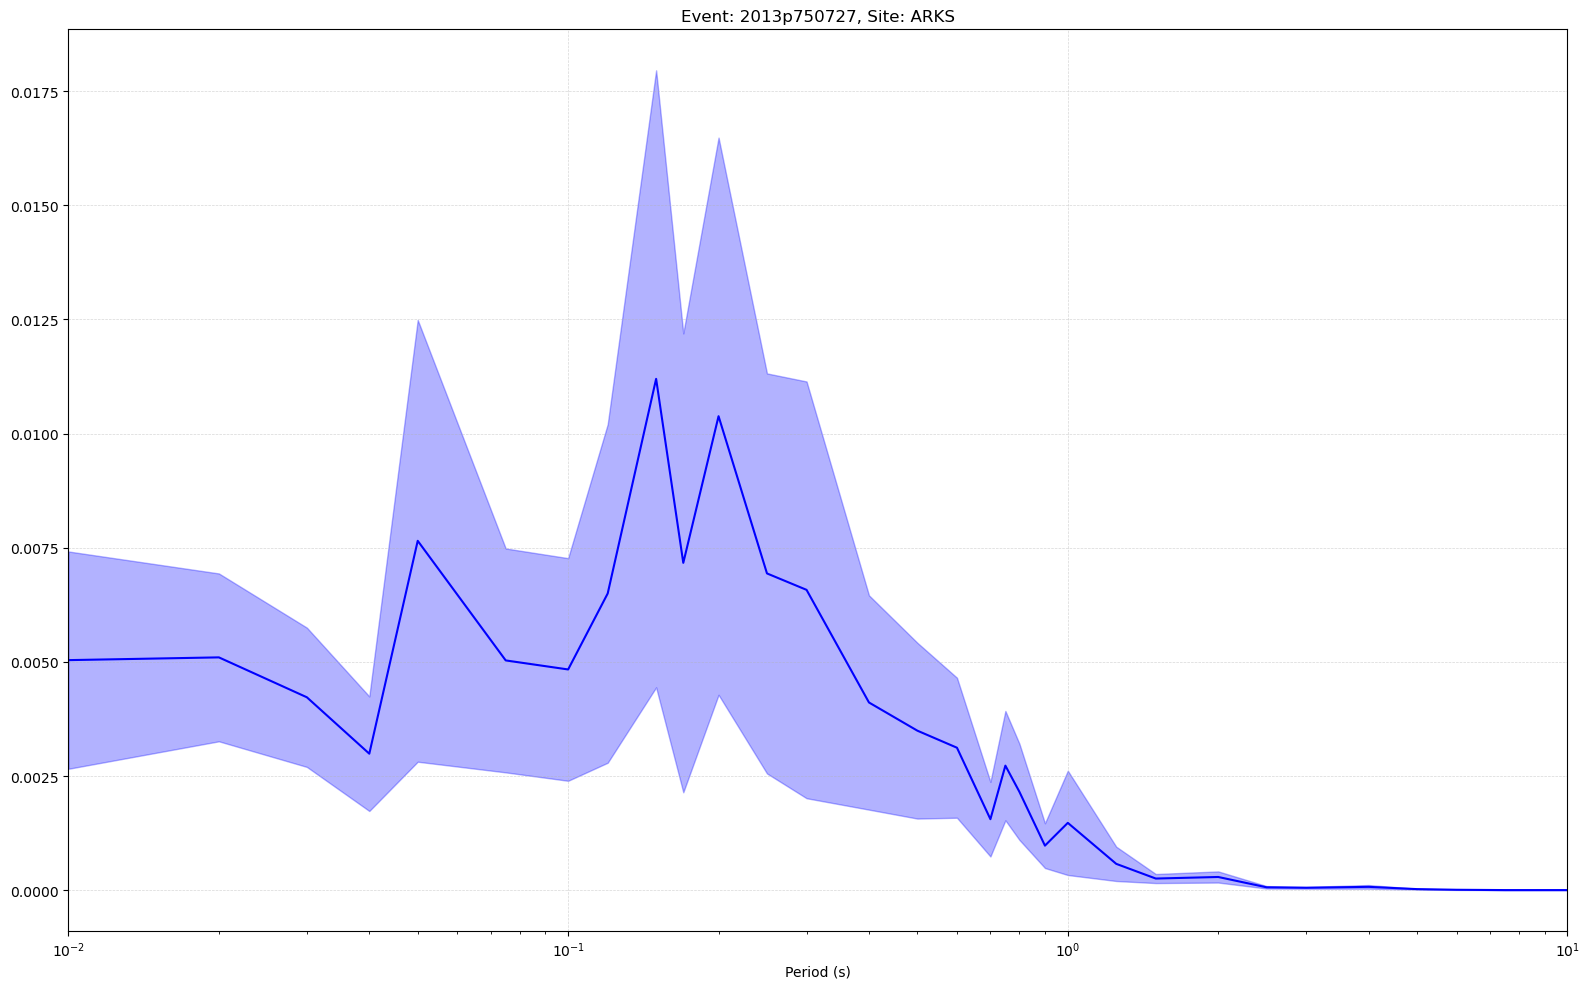

In [56]:
fig = plt.figure(figsize=(16, 10))

plt.semilogx(sr.constants.PERIODS, mean_values, c="b")
plt.fill_between(sr.constants.PERIODS, mean_values - std_values, mean_values + std_values, color="b", alpha=0.3)

plt.title(f"Event: {event}, Site: {site_int}")
plt.xlabel(f"Period (s)")
plt.ylabel(f"")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.xlim(0.01, 10)

plt.tight_layout()

## Logspace

In [71]:
mean_values_ln = einops.einsum(prob_values, np.log(sim_values), "rel im, rel im -> im")
std_values_ln = np.sqrt(np.sum(prob_values * (np.log(sim_values) - mean_values_ln[None, :])**2, axis=0))

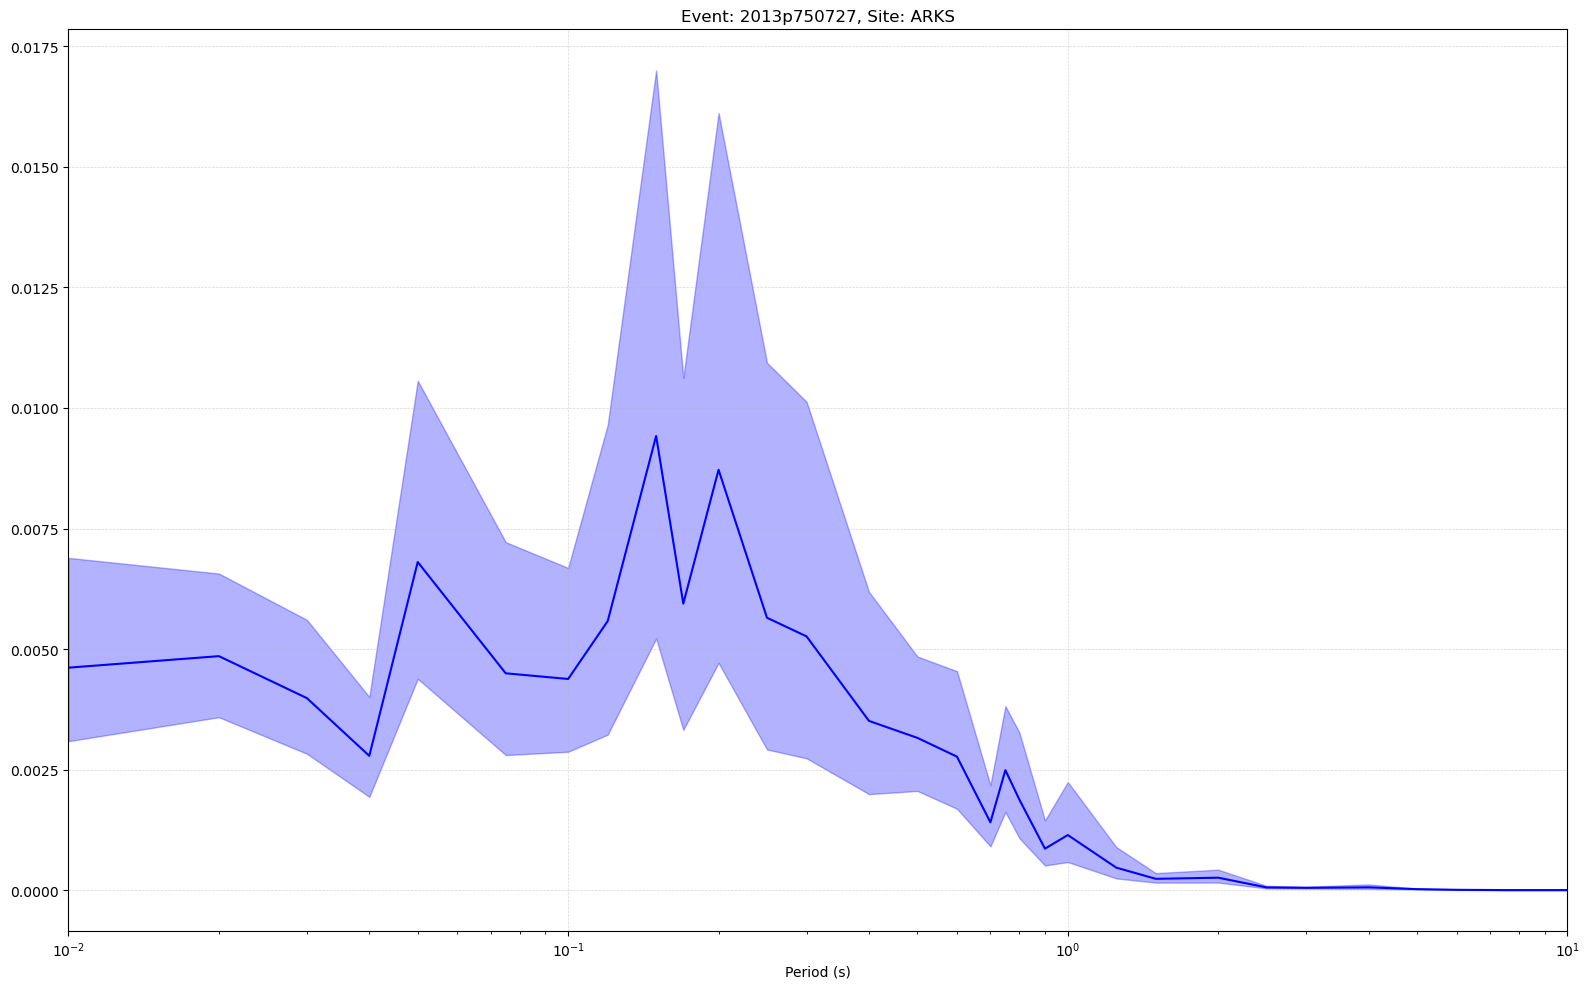

In [74]:
fig = plt.figure(figsize=(16, 10))

plt.semilogx(sr.constants.PERIODS, np.exp(mean_values_ln), c="b")
plt.fill_between(sr.constants.PERIODS, np.exp(mean_values_ln - std_values_ln), np.exp(mean_values_ln + std_values_ln), color="b", alpha=0.3)

plt.title(f"Event: {event}, Site: {site_int}")
plt.xlabel(f"Period (s)")
plt.ylabel(f"")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.xlim(0.01, 10)

plt.tight_layout()

## Comparison

In [77]:
print(mean_values)
print("------------------------------------------------------------")
print(np.exp(mean_values_ln))

[5.03799347e-03 5.09822615e-03 4.22434019e-03 2.98900003e-03
 7.65072428e-03 5.03152390e-03 4.83360639e-03 6.49764224e-03
 1.11979192e-02 7.16800786e-03 1.03796840e-02 6.93662227e-03
 6.57707571e-03 4.11056383e-03 3.49295981e-03 3.11984710e-03
 1.55485401e-03 2.72761905e-03 2.15534455e-03 9.75481654e-04
 1.47445823e-03 5.76835457e-04 2.54871995e-04 2.89115421e-04
 6.29499715e-05 5.28104355e-05 7.31362711e-05 2.33244638e-05
 9.08459763e-06 2.20192999e-06 2.36269390e-06]
------------------------------------------------------------
[4.61455450e-03 4.85329008e-03 3.98280077e-03 2.78505861e-03
 6.80504699e-03 4.49738450e-03 4.37991034e-03 5.58027152e-03
 9.41893751e-03 5.94273308e-03 8.71730006e-03 5.64944165e-03
 5.26297601e-03 3.51037513e-03 3.15835611e-03 2.76904179e-03
 1.40693357e-03 2.48949228e-03 1.87721886e-03 8.60527057e-04
 1.14388859e-03 4.67817327e-04 2.35582918e-04 2.59108544e-04
 5.73711555e-05 4.89697304e-05 5.94757872e-05 2.18598614e-05
 7.94074733e-06 2.09915180e-06 2.09304

In [79]:
mean_values - np.exp(mean_values_ln)

array([4.23438977e-04, 2.44936069e-04, 2.41539416e-04, 2.03941419e-04,
       8.45677293e-04, 5.34139409e-04, 4.53696048e-04, 9.17370725e-04,
       1.77898173e-03, 1.22527478e-03, 1.66238390e-03, 1.28718061e-03,
       1.31409970e-03, 6.00188697e-04, 3.34603695e-04, 3.50805309e-04,
       1.47920440e-04, 2.38126771e-04, 2.78125685e-04, 1.14954597e-04,
       3.30569643e-04, 1.09018130e-04, 1.92890769e-05, 3.00068773e-05,
       5.57881601e-06, 3.84070511e-06, 1.36604839e-05, 1.46460244e-06,
       1.14385030e-06, 1.02778193e-07, 2.69650549e-07])

In [81]:
std_values 

array([2.37920328e-03, 1.83806340e-03, 1.52503555e-03, 1.25460497e-03,
       4.83747204e-03, 2.45163331e-03, 2.43781257e-03, 3.70662493e-03,
       6.75618016e-03, 5.02444567e-03, 6.10097771e-03, 4.38024870e-03,
       4.56339963e-03, 2.34675811e-03, 1.92477804e-03, 1.53318404e-03,
       8.16512328e-04, 1.19718778e-03, 1.05391269e-03, 4.90108427e-04,
       1.14214018e-03, 3.75740825e-04, 9.92198199e-05, 1.21890824e-04,
       2.67811417e-05, 2.03151991e-05, 3.95828437e-05, 8.94193359e-06,
       4.03884061e-06, 7.48933189e-07, 1.17305364e-06])

In [82]:
std_values_ln

array([0.40105893, 0.30232207, 0.34195784, 0.36393473, 0.43975418,
       0.47303954, 0.42253057, 0.54776315, 0.59057087, 0.58094985,
       0.61463962, 0.66066274, 0.65459198, 0.56658422, 0.42804233,
       0.4947597 , 0.43717841, 0.42771738, 0.55463566, 0.51865676,
       0.67336221, 0.64830684, 0.40861067, 0.49606923, 0.44407274,
       0.39744334, 0.69920923, 0.35757423, 0.55988584, 0.30279002,
       0.49508903])